# Setup

In [415]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D  
import matplotlib.animation as pltanim
import numpy as np
import seaborn as sns

In [1113]:
def get_z_sample(mean, transf, num_samples = 1):
    expanded_mean = mean[:, None].expand(-1, num_samples, -1)
    noise = torch.einsum("nij,nsj->nsi", transf, torch.randn_like(expanded_mean))
    z_samples = expanded_mean + noise
    return z_samples

def get_cross_sample(mapper, in_mean, in_transf, num_samples = 1):
    direct_sample = get_z_sample(in_mean, in_transf, 1)[:, 0]
    (out_mean, out_transf) = mapper(direct_sample)
    cross_sample = get_z_sample(out_mean, out_transf, num_samples)
    return (direct_sample, cross_sample, out_mean, out_transf)

def get_dense(input_size, output_size, hidden_dims, actvs = None, final_bias = True):
    layer_sizes = [input_size] + hidden_dims + [output_size]
    if type(actvs) != list:
        actvs = [actvs]*len(layer_sizes[1:])
    layers = []
    for (i, (input_dim, output_dim, actv)) in enumerate(zip(layer_sizes[:-1], layer_sizes[1:], actvs)):
        bias = (final_bias if i == len(hidden_dims) else True)
        layers.append(torch.nn.Linear(input_dim, output_dim, bias = bias))
        if actv is not None:
            layers.append(actv())
    return layers

def combine_losses(total_loss, cuml_losses, new_losses):
    incremented = {key:value + cuml_losses.get(key, 0) for (key, value) in new_losses.items()}
    cuml_total = cuml_losses.get("total", 0) + total_loss
    new_cuml = {**cuml_losses, **incremented, "total": cuml_total}
    return new_cuml

def plot_gradient(ax, decoder, scale = None):
    n = 50 + 1
    delta = 0.1
    points = torch.linspace(-3, 3, n)
    z_grid = torch.stack(torch.meshgrid(points, points), -1)
    displ = torch.asarray([[delta, 0], [0, delta], [delta/2**0.5, delta/2**0.5], [delta/2**0.5, -delta/2**0.5]])
    (plus, minus) = (z_grid[:, :, None] + displ[None, None], z_grid[:, :, None] - displ[None, None])
    (plus_f, minus_f) = (plus.reshape(4*n**2, 2), minus.reshape(4*n**2, 2))
    with torch.no_grad():
        (output_plus, output_minus) = (decoder(plus_f.float()), decoder(minus_f.float()))
    grad = (output_plus - output_minus) / (2*delta)
    combined = abs(grad).reshape(n, n, 4, -1).sum(-1)
    (max_val, max_dir) = torch.max(combined, -1)
    (max_dir, max_val) = (max_dir.reshape(n, n), max_val.reshape(n, n))
    scale = max_val.max() if scale is None else scale
    max_val = max_val / scale

    lines = displ
    for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
        for (xy, dir, val) in zip(coords, row_dirs, row_vals):
            ((px_1, py_1), (px_2, py_2)) = (xy + lines[dir]*val, xy - lines[dir]*val)
            ax.plot([px_1, px_2], [py_1, py_2], color = "black", linewidth = 0.5)
    return (z_grid, combined)

class Encoder(torch.nn.Module):
    def __init__(self, input_dim, init_hidden, mean_hidden, transf_hidden, latent_dim):
        super().__init__()
        init_out = init_hidden[-1] if init_hidden else input_dim
        initial_layers = get_dense(input_dim, init_out, init_hidden[:-1], torch.nn.ReLU) if init_hidden else []
        mean_actvs = [torch.nn.ReLU]*len(mean_hidden) + [None]
        transf_actvs = [torch.nn.ReLU]*len(transf_hidden) + [None]

        self.initial_segment = torch.nn.Sequential(*initial_layers)
        self.mean_layer = torch.nn.Sequential(*get_dense(init_out, latent_dim, mean_hidden, mean_actvs, False))
        self.transf_layer = torch.nn.Sequential(*get_dense(init_out, latent_dim**2, transf_hidden, transf_actvs))
        
        self.softplus = torch.nn.Softplus()
        self.bn = torch.nn.BatchNorm1d(latent_dim, momentum = 0.05, affine = False)
        self.latent_dim = latent_dim
    
    def forward(self, x):
        x = self.initial_segment(x)
        # mean = self.bn(self.mean_layer(x))
        mean = self.mean_layer(x)
        transf_raw = self.transf_layer(x).reshape(-1, self.latent_dim, self.latent_dim)
        diagonals = self.softplus(torch.diagonal(transf_raw, 0, -2, -1)) + 1e-4
        transf = torch.diag_embed(diagonals) + torch.tril(transf_raw, -1)
        return (mean, transf)
    
class Decoder(torch.nn.Module):
    def __init__(self, output_dim, hidden_dims, latent_dim):
        super().__init__()
        actvs = [torch.nn.ReLU]*len(hidden_dims) + [None]
        self.network = torch.nn.Sequential(*get_dense(latent_dim, output_dim, hidden_dims, actvs))

    def forward(self, x):
        x = self.network(x)
        return x

class Mapper(torch.nn.Module):
    def __init__(self, hidden, latent_dim):
        super().__init__()
        actvs = [torch.nn.ReLU]*len(hidden) + [None]
        self.transf_layer = torch.nn.Sequential(*get_dense(latent_dim, latent_dim**2, hidden, actvs))
        self.softplus = torch.nn.Softplus()
        self.latent_dim = latent_dim

    def forward(self, z):
        transf_raw = self.transf_layer(z).reshape(-1, self.latent_dim, self.latent_dim)
        diagonals = self.softplus(torch.diagonal(transf_raw, 0, -2, -1)) + 1e-4
        transf = torch.diag_embed(diagonals) + torch.tril(transf_raw, -1)
        mean = z
        return (mean, transf)

class VariationalLoss():
    def __init__(self, num_modalities, recon_frac, cross_damp, within_var, cross_var, num_samples = 1):
        self.modalities = list(range(num_modalities))
        self.num_samples = num_samples
        self.recon_frac = recon_frac
        self.within_var = within_var
        self.cross_var = cross_var
        self.cross_damp = cross_damp
    
    def process_batch(self, encoders, decoders, mappers, x_list):
        (latent_dict, mapper_dict, loss_dict) = ({}, {}, {})
        for modal in self.modalities:
            (enc, dec, x) = (encoders[modal], decoders[modal], x_list[modal])
            (z_mean, z_transf) = enc(x)
            latent_dict[modal] = (z_mean, z_transf)
            loss_dict[modal] = self.get_within_loss(enc, dec, x, z_mean, z_transf, self.num_samples)
            for (prev_modal, (prev_mean, prev_transf)) in list(latent_dict.items())[:-1]:
                (map_prev_cur, map_cur_prev) = (mappers[(prev_modal, modal)], mappers[(modal, prev_modal)])
                (_, cross_sample, cross_mean, cross_transf) = get_cross_sample(map_cur_prev, z_mean, z_transf, self.num_samples)
                (_, prev_cross_sample, prev_cross_mean, prev_cross_transf) = get_cross_sample(map_prev_cur, prev_mean, prev_transf, self.num_samples)
                mapper_dict[f"{prev_modal}={modal}"] = (prev_cross_mean, prev_cross_transf)
                mapper_dict[f"{modal}={prev_modal}"] = (cross_mean, cross_transf)
                
                (prev_x, prev_dec) = (x_list[prev_modal], decoders[prev_modal])
                cross_loss = self.get_cross_loss(prev_dec, prev_x, cross_sample)
                prev_cross_loss = self.get_cross_loss(dec, x, prev_cross_sample)
                loss_dict[f"{modal}={prev_modal}"] = cross_loss
                loss_dict[f"{prev_modal}={modal}"] = prev_cross_loss
        (weighted_loss_dict, total_loss) = self.combine_losses(loss_dict, latent_dict, mapper_dict)
        return (weighted_loss_dict, total_loss)

    def reconstruction_loss(self, x, x_recon):
        squared_diff = torch.square(x[:, None] - x_recon)
        loss = squared_diff.sum() / (x_recon.shape[0]*x_recon.shape[1])
        return loss

    def get_within_loss(self, encoder, decoder, x, z_mean, z_transf, num_samples):
        z_sample = get_z_sample(z_mean, z_transf, num_samples)
        xr = decoder(z_sample.flatten(0, 1)).unflatten(0, z_sample.shape[:2]) 
        loss = self.reconstruction_loss(x, xr)
        return loss
    
    def get_cross_loss(self, out_decoder, x, cross_sample):
        xr = out_decoder(cross_sample.flatten(0, 1)).unflatten(0, cross_sample.shape[:2])
        loss = self.reconstruction_loss(x, xr)
        return loss

    def combine_losses(self, loss_dict, latent_dict, mapper_dict):
        (recon_weight, reg_weight) = (self.recon_frac, 1 - self.recon_frac)
        weighted_loss_dict = {}
        total_loss = 0
        for modal_1 in self.modalities:
            (mean_1, transf_1) = latent_dict[modal_1]
            losses = {
                "within": recon_weight*loss_dict[modal_1],
                "mean_reg": reg_weight*0.5*torch.square(mean_1).sum(1).mean() / self.within_var,
                "trace_reg": reg_weight*0.5*transf_1.square().mean(0).sum() / self.within_var,
                "det_reg": -reg_weight*0.5*(2*torch.log(torch.det(transf_1)).mean())
                }
            total_loss += sum(loss for loss in losses.values())
            weighted_loss_dict = {
                **weighted_loss_dict, 
                **{f"{modal_1}_{key}": loss for (key, loss) in losses.items()}}
            for modal_2 in self.modalities:
                if modal_1 != modal_2:
                    for (first, second) in [(modal_1, modal_2), (modal_2, modal_1)]:
                        (_, map_transf) = mapper_dict[f"{first}={second}"]
                        losses = {
                            "cross": self.cross_damp*recon_weight*loss_dict[f"{first}={second}"],
                            "map_trace_reg": reg_weight*0.5*map_transf.square().mean(0).sum() / self.cross_var,
                            "map_det_reg": -reg_weight*0.5*(2*torch.log(torch.det(map_transf)).mean()) / self.cross_var}
                        total_loss += sum(loss for loss in losses.values())
                        weighted_loss_dict = {
                            **weighted_loss_dict,
                            **{f"{first}-{second}_{key}": loss for (key, loss) in losses.items()}}
        return (weighted_loss_dict, total_loss)

class ClusterData():
    def __init__(self, cluster_params, cluster_probs):
        self.num_clusters = len(cluster_params)
        self.dims = [len(mean) for mean in cluster_params[0]["means"]]
        self.num_modalities = len(self.dims)
        self.gaussians = [self.get_cluster_gaussian(**params) for params in cluster_params]
        self.probs = torch.as_tensor(cluster_probs)
        self.modal_slices = self.get_modal_slices()

    def get_cluster_gaussian(self, means, vars, within_corrs, cross_corr):
        mean_comb = torch.as_tensor(means).flatten().float()
        within_blocks = {(i, i): self.get_modality_cov_block(self.dims[i], vars[i], within_corrs[i]) 
                         for i in range(self.num_modalities)}
        cross_blocks = {(i, j): self.get_cross_block(self.dims[i], self.dims[j], vars[i], vars[j], cross_corr)
                        for i in range(self.num_modalities) for j in range(self.num_modalities)
                        if i != j}
        blocks = {**within_blocks, **cross_blocks}
        cov = torch.cat([torch.cat([blocks[(i, j)] for j in range(self.num_modalities)], 1)
                         for i in range(self.num_modalities)], 0)
        transf = torch.linalg.cholesky(cov)
        return {"mean": mean_comb, "cov": cov, "transf": transf}
        
    def get_modality_cov_block(self, dim, var, corr):
        cov = torch.ones([dim, dim])*var*corr
        torch.diagonal(cov).copy_(var*torch.ones([dim]))
        return cov

    def get_cross_block(self, rows, cols, row_var, col_var, cross_corr):
        row_vec = torch.full([rows], row_var)
        col_vec = torch.full([cols], col_var)
        cross_block = cross_corr*torch.sqrt(row_vec[:, None]*col_vec[None])
        return cross_block

    def get_modal_slices(self):
        cuml_pos = np.insert(np.cumsum(self.dims[:-1]), 0, 0)
        modal_slices = [(slice(None), slice(int(pos), int(pos + dim), 1))
                         for (pos, dim) in zip(cuml_pos, self.dims)]
        return modal_slices

    def get_cluster_sample(self, cluster, num_samples):
        params = self.gaussians[cluster]
        expanded_mean = params["mean"][None].expand(num_samples, -1)
        noise = torch.einsum("ij,sj->si", params["transf"], torch.randn_like(expanded_mean))
        samples = expanded_mean + noise
        return samples
    
    def sample(self, num_samples, clusters = None, modalities = None):
        if clusters is not None:
            excl_clusters = torch.as_tensor([i for i in range(self.num_clusters) if i not in clusters])
            probs = self.probs.scatter(0, excl_clusters, torch.zeros_like(excl_clusters, dtype = torch.float32))
        else:
            probs = self.probs
        if modalities is not None:
            modal_slices = [modal_slice for (i, modal_slice) in enumerate(self.modal_slices) if i in modalities]
        else:
            modal_slices = self.modal_slices
        cluster_labels = torch.multinomial(probs, num_samples, replacement = True)
        cluster_counts = torch.unique(cluster_labels, return_counts = True)[-1]
        samples = torch.cat([self.get_cluster_sample(i, counts) for (i, counts) in enumerate(cluster_counts)], 0)
        permutation = torch.randperm(num_samples)
        cluster_labels = torch.sort(cluster_labels, dim = 0)[0][permutation]
        samples = samples[permutation]
        modal_samples = [samples[slices] for slices in modal_slices]
        return (modal_samples, cluster_labels)

# Experiments

In [1119]:
(dim, num_modal) = (2, 2)
# cluster_params = [
#     {"means": [[-1]*dim]*num_modal,
#      "vars": [0.15]*num_modal,
#      "within_corrs": [0.0]*num_modal,
#      "cross_corr": 0.0},
#     # {"means": [[0]*dim]*num_modal,
#     #  "vars": [0.1]*num_modal,
#     #  "within_corrs": [0.0]*num_modal,
#     #  "cross_corr": 0.0},
#      {"means": [[1]*dim]*num_modal,
#      "vars": [0.15]*num_modal,
#      "within_corrs": [0.0]*num_modal,
#      "cross_corr": 0.0}
# ]
cluster_params = [
    {"means": [[-2, -1] + [0]*(dim - 2)]*num_modal,
     "vars": [0.2]*num_modal,
     "within_corrs": [0.0]*num_modal,
     "cross_corr": 0.0},
    {"means": [[0, 2*3**0.5/2] + [0]*(dim - 2)]*num_modal,
     "vars": [0.2]*num_modal,
     "within_corrs": [0.0]*num_modal,
     "cross_corr": 0.0},
     {"means": [[2, -1] + [0]*(dim - 2)]*num_modal,
     "vars": [0.2]*num_modal,
     "within_corrs": [0.0]*num_modal,
     "cross_corr": 0.0}
]
cluster_probs = [1.0]*len(cluster_params)
cluster_data = ClusterData(cluster_params, cluster_probs)
(num_modalities, num_clusters) = (cluster_data.num_modalities, cluster_data.num_clusters)
modality_dims = cluster_data.dims
colors = sns.color_palette("colorblind", np.max(num_clusters + 1))
latent_dims = [2]*num_modal

In [1120]:
num_samples = 10000
(samples, cluster_labels) = cluster_data.sample(num_samples)

In [1140]:
within_var = 1.0
cross_var = 10.0
recon_frac = 1.0
cross_damp = 1.0
var_loss = VariationalLoss(num_modalities, recon_frac, cross_damp, within_var, cross_var)

In [1141]:
encoder_layers = [
    {"init_hidden": [], "mean_hidden": [100, 100], "transf_hidden": [100, 100]},
    {"init_hidden": [], "mean_hidden": [100, 100], "transf_hidden": [100, 100]}]
decoder_layers = [[100, 100], [100, 100]]
mapper_layers = [100, 100]

encoders = [Encoder(input_dim = modal_dim, latent_dim = latent_dim, **layers)
            for (modal_dim, latent_dim, layers) in zip(modality_dims, latent_dims, encoder_layers)]
decoders = [Decoder(modal_dim, layers, latent_dim)
            for (modal_dim, latent_dim, layers) in zip(modality_dims, latent_dims, decoder_layers)]
mappers = {(i, j): Mapper(mapper_layers, latent_dims[j]) 
           for i in range(num_modalities) for j in range(num_modalities) if i != j}
model = torch.nn.ModuleDict({
    "encoders": torch.nn.ModuleList(encoders),
    "decoders": torch.nn.ModuleList(decoders),
    "mappers": torch.nn.ModuleList(list(mappers.values()))})

In [1142]:
epochs = int(2000*10000/num_samples)
batch_size = 1024
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

for epoch in range(epochs):
    try:
        shuffled_indices = torch.randperm(num_samples)
        cuml_losses = {}
        batch_starts = list(range(0, num_samples, batch_size))
        for start in batch_starts:
            optimizer.zero_grad()
            batch_indices = shuffled_indices[start:start + batch_size]
            batched_data = [modal_samples[batch_indices] for modal_samples in samples]
            (loss_dict, loss) = var_loss.process_batch(encoders, decoders, mappers, batched_data)
            loss.backward()
            optimizer.step()
            cuml_losses = combine_losses(loss, cuml_losses, loss_dict)
        avg_losses = {key: value / len(batch_starts) for (key, value) in cuml_losses.items()}
        print(f"Epoch {epoch + 1}: {avg_losses['total'].item():.4f}")
    except KeyboardInterrupt:
        break

Epoch 1: 26.1862
Epoch 2: 15.3169
Epoch 3: 5.7717
Epoch 4: 3.0078
Epoch 5: 2.5859
Epoch 6: 2.4342
Epoch 7: 2.3634
Epoch 8: 2.3084
Epoch 9: 2.2661
Epoch 10: 2.2372
Epoch 11: 2.2174
Epoch 12: 2.2012
Epoch 13: 2.1787
Epoch 14: 2.1737
Epoch 15: 2.1616
Epoch 16: 2.1492
Epoch 17: 2.1399
Epoch 18: 2.1352
Epoch 19: 2.1281
Epoch 20: 2.1260
Epoch 21: 2.1202
Epoch 22: 2.1114
Epoch 23: 2.1062
Epoch 24: 2.1051
Epoch 25: 2.0957
Epoch 26: 2.0861
Epoch 27: 2.0876
Epoch 28: 2.0800
Epoch 29: 2.0765
Epoch 30: 2.0672
Epoch 31: 2.0640
Epoch 32: 2.0565
Epoch 33: 2.0533
Epoch 34: 2.0436
Epoch 35: 2.0335
Epoch 36: 2.0288
Epoch 37: 2.0165
Epoch 38: 1.9975
Epoch 39: 1.9892
Epoch 40: 1.9767
Epoch 41: 1.9657
Epoch 42: 1.9600
Epoch 43: 1.9486
Epoch 44: 1.9418
Epoch 45: 1.9366
Epoch 46: 1.9287
Epoch 47: 1.9196
Epoch 48: 1.9158
Epoch 49: 1.9115
Epoch 50: 1.9095
Epoch 51: 1.9040
Epoch 52: 1.9001
Epoch 53: 1.9018
Epoch 54: 1.8950
Epoch 55: 1.8944
Epoch 56: 1.8969
Epoch 57: 1.8911
Epoch 58: 1.8876
Epoch 59: 1.8841
Epoc

# Analysis

In [1124]:
count = 100
subset = [modal_samples[::count] for modal_samples in samples]

### Original Data

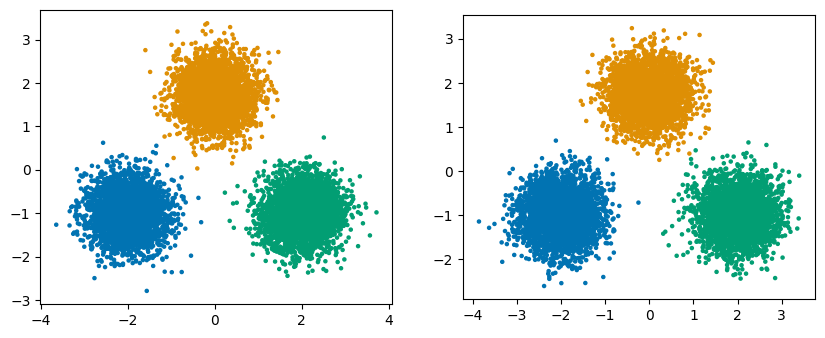

In [1126]:
(fig, axes) = plt.subplots(ncols = num_modalities, figsize = (10, 10), squeeze = False)
for (ax, x) in zip(axes[0], [modal_samples[:10000] for modal_samples in samples]):
    ax.scatter(x[:, 0], x[:, 1], s = 5, color = [colors[index] for index in cluster_labels[:10000]])
    ax.set_aspect(1)
# plt.savefig("cov_presentation/cluster_data_1.png")
plt.show()

### Reconstruction

In [1147]:
with torch.no_grad():
    modal_means = [encoder(x)[0] for (x, encoder) in zip(subset, encoders)]
    mapped_recons = {(i, j): decoders[j](mapper(modal_means[i])[0]) for ((i, j), mapper) in mappers.items()} 
    direct_recons = {(i, i): decoder(z) for (i, (z, decoder)) in enumerate(zip(modal_means, decoders))}
    recons = {**direct_recons, **mapped_recons}

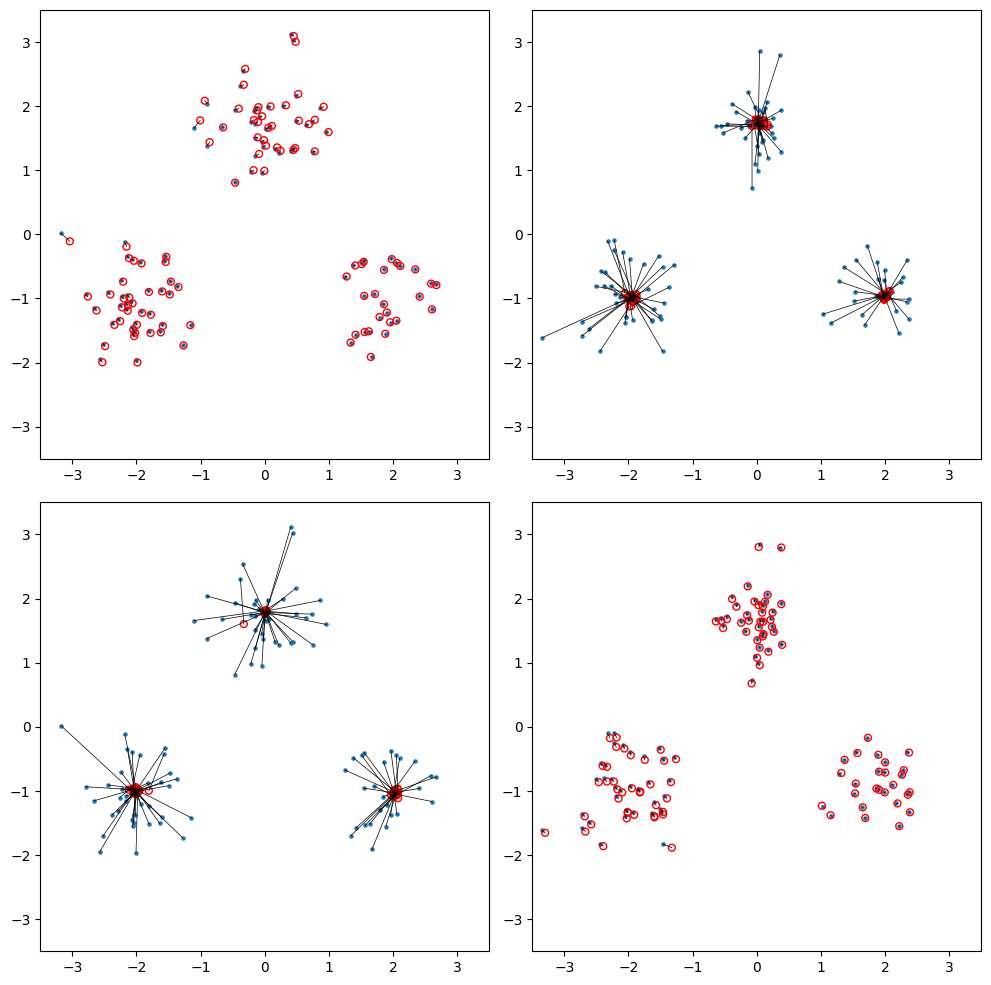

In [1148]:
(fig, axes) = plt.subplots(nrows = num_modalities, ncols = num_modalities, figsize = (10, 10), squeeze = False)
for (input_modal, ax_list) in enumerate(axes):
    for (output_modal, ax) in enumerate(ax_list):
        x = subset[output_modal]
        x_recon = recons[(input_modal, output_modal)]
        ax.scatter(x[:, 0], x[:, 1], s = 5)
        ax.scatter(x_recon[:, 0], x_recon[:, 1], s = 25, facecolors = "none", edgecolors = "r")
        for ((x_0, x_1), (xr_0, xr_1)) in zip(x[:, :2], x_recon[:, :2]):
            ax.plot([x_0, xr_0], [x_1, xr_1], color = "black", linewidth = 0.5)
        ax.set_aspect(1)
        ax.set_xlim([-3.5, 3.5])
        ax.set_ylim([-3.5, 3.5])
plt.tight_layout()
# plt.savefig("cov_presentation/multimodal_recon.png")
plt.show()

### Latent Space

In [1144]:
(means, covs, eig_vals, eig_vecs, rotations) = ({}, {}, {}, {}, {})
with torch.no_grad():
    modal_latent = [encoder(x[::100]) for (x, encoder) in zip(samples, encoders)]
    for (in_modal, (mean, transf)) in enumerate(modal_latent):
        for out_modal in range(num_modalities):
            modals = (in_modal, out_modal)
            if in_modal != out_modal:
                (mean, transf) = mappers[modals](mean)
            means[modals] = mean
            covs[modals] = torch.einsum("nij,nkj->nik", transf, transf)
            (eig_vals[modals], eig_vecs[modals]) = torch.linalg.eigh(covs[modals])
            rotations[modals] = 180*torch.arccos(eig_vecs[modals][:, 1, 0])/np.pi

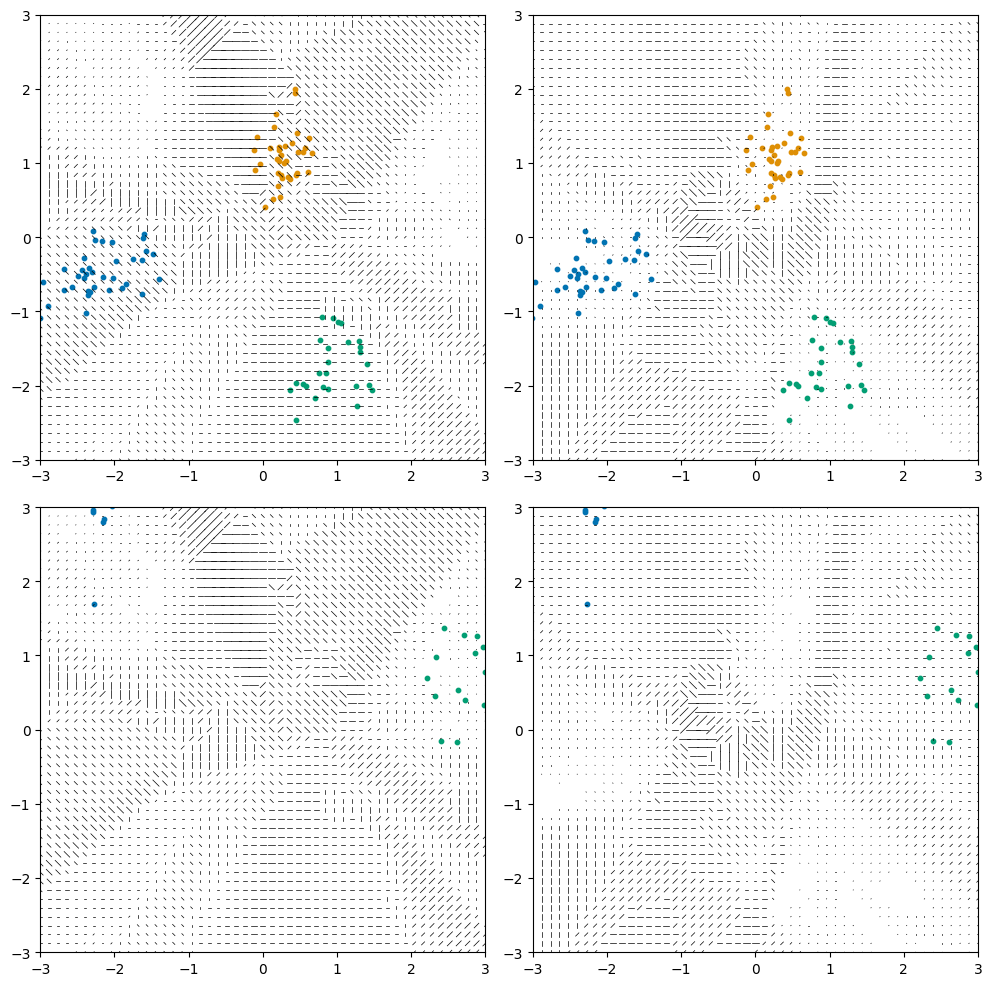

In [1145]:
gradients = {}
(fig, axes) = plt.subplots(nrows = num_modalities, ncols = num_modalities, figsize = (10, 10), squeeze = False)
colors = sns.color_palette("colorblind", np.max(num_clusters + 1))
for (in_modal, in_axes) in enumerate(axes):
    for (out_modal, (ax, dec)) in enumerate(zip(in_axes, decoders)):
        modals = (in_modal, out_modal)
        (z_grid, gradients[modals]) = plot_gradient(ax, dec)
        for ((x, y), (min_eig, max_eig), angle, color_index) in zip(means[modals], eig_vals[modals], rotations[modals], cluster_labels[::100]):
            color = colors[color_index]
            ellipse = Ellipse(xy = (x, y), width = max_eig**0.5, height = min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
            ax.add_patch(ellipse)
            ax.scatter([x], [y], s = 10, color = color)
        ax.set_aspect(1)
        ax.set_xlim([-3, 3])
        ax.set_ylim([-3, 3])
plt.tight_layout()
# plt.savefig("cov_presentation/multimodal_latent.png")
plt.show()

# Loss Landscape

In [ ]:
bounds = 0.1
n = 101
points = torch.stack(torch.meshgrid(torch.linspace(-bounds, bounds, n), torch.linspace(-bounds, bounds, n)), -1)
z_points = points[None] + means[(0, 0)][:, None, None]
with torch.no_grad():
    recons = decoders[0](z_points.flatten(0, 2).float()).unflatten(0, z_points.shape[:3])
mse = torch.square(samples[0][:200, None, None] - recons).mean(-1)

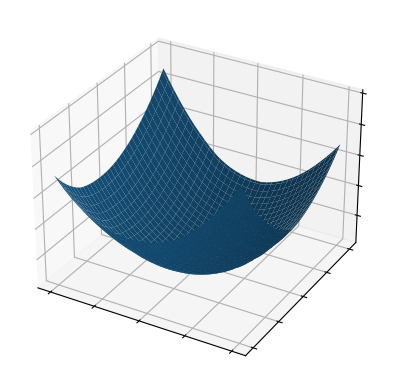

In [ ]:

i = 9

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.plot_surface(points[:, :, 0], points[:, :, 1], mse[i])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

plt.show()

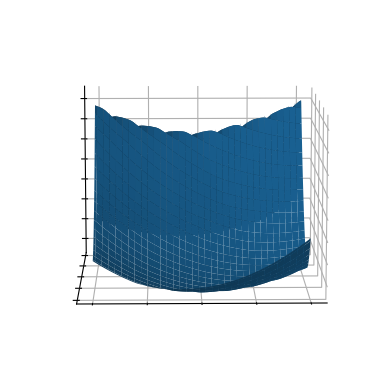

/var/folders/l8/m2glkk_557l1j7xyp1qbh99m0000gp/T/ipykernel_88549/1134383596.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


In [ ]:
i = 5

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

def init():
    ax.plot_surface(points[:, :, 0], points[:, :, 1], mse[i])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))

def update(frame):
    ax.view_init(elev = 10, azim = frame)

animation = pltanim.FuncAnimation(fig, update, np.arange(90, 450), init_func = init)
writer = pltanim.PillowWriter(fps = 30)
# animation.save(f"cov_presentation/loss_{i}.gif", writer = writer)
plt.show()

# Presentation

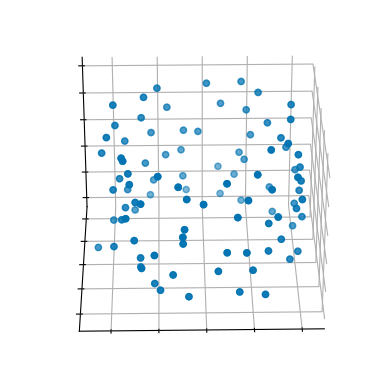

In [1035]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

def init():
    color_indices = [colors[i] for i in cluster_labels[:100]]
    ax.scatter(samples[0][::100, 0], samples[0][::100, 1], samples[0][::100, 2], 
               color = color_indices)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))

def update(frame):
    ax.view_init(azim = frame)

animation = pltanim.FuncAnimation(fig, update, np.arange(90, 450), init_func = init)
writer = pltanim.PillowWriter(fps = 30)
animation.save("cov_presentation/ae_input_test.gif", writer = writer, savefig_kwargs = dict(facecolor='#FFFFFF'))


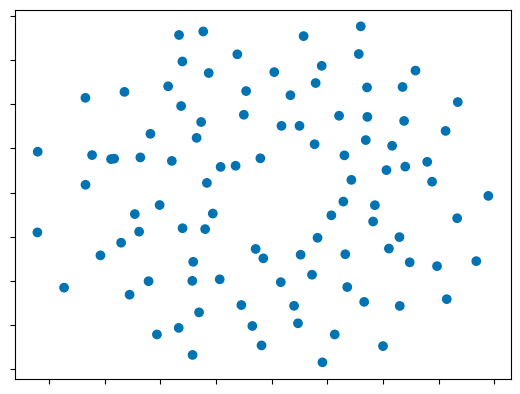

In [1044]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(means[(0, 0)][:100, 0], means[(0, 0)][:100, 1], color = [colors[i] for i in cluster_labels[:100]])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.savefig("cov_presentation/ae_latent_test.png")

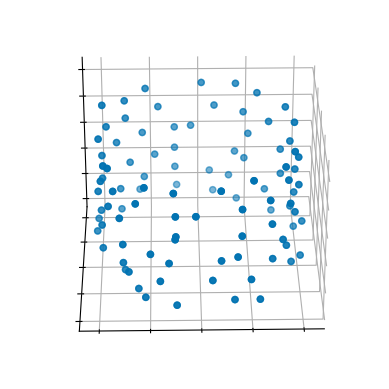

In [1045]:

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")

def init():
    data = recons[(0, 0)]
    color_indices = [colors[i] for i in cluster_labels[::100]]
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], 
               color = color_indices)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))

def update(frame):
    ax.view_init(azim = frame)

animation = pltanim.FuncAnimation(fig, update, np.arange(90, 450), init_func = init)
writer = pltanim.PillowWriter(fps = 30)
animation.save("cov_presentation/ae_output_test.gif", writer = writer)

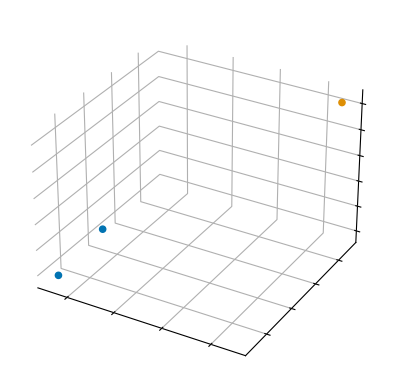

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.scatter(samples[0][:3, 0], samples[0][:3, 1], samples[0][:3, 2], color = [colors[i] for i in cluster_labels[:3]], depthshade = False)
ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
plt.savefig("cov_presentation/vae_input.png")

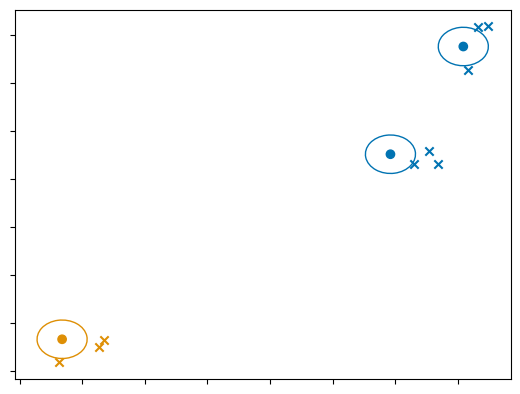

In [ ]:

plt_means = means[(0, 0)][:3]
plt_expanded_means = plt_means[:, None].expand(-1, 3, -1)
plt_samples = plt_expanded_means + 0.1*torch.randn_like(plt_expanded_means)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(plt_means[:, 0], plt_means[:, 1], color = [colors[i] for i in cluster_labels[:3]])
for ((x_0, y_0), sample_set, color_i) in zip(plt_means, plt_samples, cluster_labels):
    ellipse = Ellipse(xy = (x_0, y_0), width = 0.2, height = 0.2, angle = angle, edgecolor = colors[color_i], fc = 'None', lw = 1)
    ax.add_patch(ellipse)
    for (x, y) in sample_set:
        ax.scatter([x], [y], marker = "x", color = colors[color_i])
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.savefig("cov_presentation/vae_latent.png")

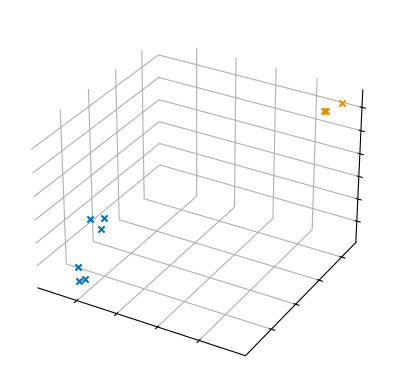

In [ ]:
plt_mean_recons = recons[(input_modal, output_modal)][:3]

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
# ax.scatter(plt_mean_recons[:, 0], plt_mean_recons[:, 1], plt_mean_recons[:, 2], color = [colors[i] for i in cluster_labels[:3]], depthshade = False)
for (sample_set, color_i) in zip(plt_samples, cluster_labels):
    with torch.no_grad():
        plt_recon = decoders[0](sample_set)
    ax.scatter(plt_recon[:, 0], plt_recon[:, 1], plt_recon[:, 2], color = colors[color_i], depthshade = False, marker = "x")
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.get_xaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_yaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.get_zaxis().set_pane_color((1.0, 1.0, 1.0, 1.0))
plt.savefig("cov_presentation/vae_output.png")

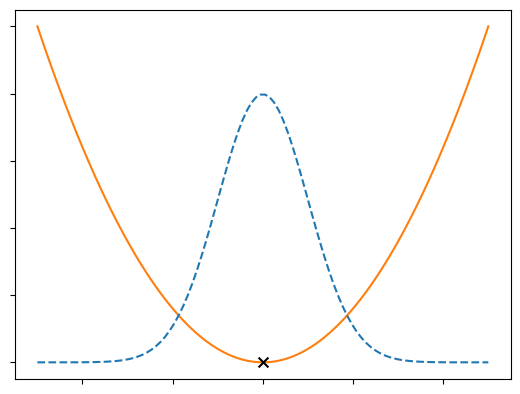

In [ ]:
x_points = torch.linspace(-5, 5, 100)
gaussian_points = torch.exp(-0.5*x_points**2)/(2*np.pi)**0.5
quadratic = 0.02*x_points**2
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_points, gaussian_points, linestyle = "dashed", zorder = 1)
ax.plot(x_points, quadratic, zorder = 0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.scatter([0], [0], color = "black", marker = "x", s = 50, zorder = 2)
plt.savefig("cov_presentation/1d_loss_optimal.png")

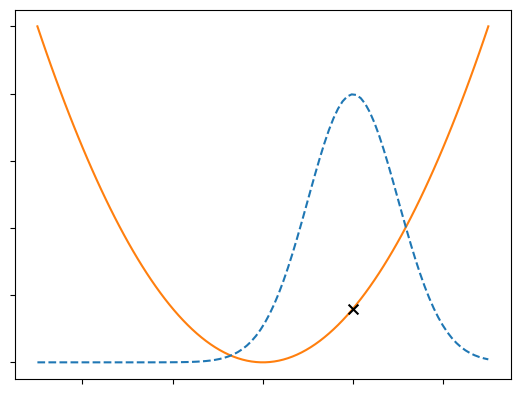

In [ ]:
x_points = torch.linspace(-5, 5, 100)
gaussian_points = torch.exp(-0.5*(x_points - 2)**2)/(2*np.pi)**0.5
quadratic = 0.02*x_points**2
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_points, gaussian_points, linestyle = "dashed", zorder = 1)
ax.plot(x_points, quadratic, zorder = 0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.scatter([2], [0.02*2**2], color = "black", marker = "x", s = 50, zorder = 2)
plt.savefig("cov_presentation/1d_loss_quad.png")

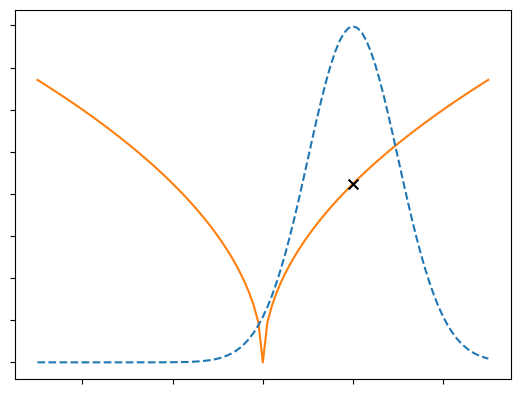

In [ ]:
x_points = torch.linspace(-5, 5, 101)
gaussian_points = torch.exp(-0.5*(x_points - 2)**2)/(2*np.pi)**0.5
sharp_well = 1.5*abs(0.01*x_points)**0.5
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_points, gaussian_points, linestyle = "dashed", zorder = 1)
ax.plot(x_points, sharp_well, zorder = 0)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.scatter([2], [1.5*0.02**0.5], color = "black", marker = "x", s = 50, zorder = 2)
plt.savefig("cov_presentation/1d_loss_root.png")